In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Set index col name to job_index
df.index.name = 'job_index'

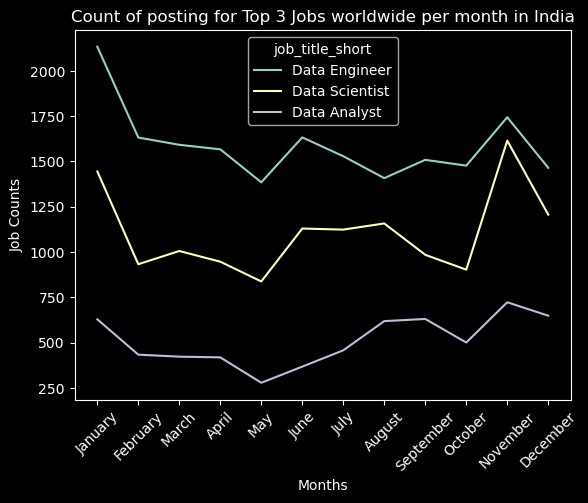

In [15]:
df_india_jobs = df[df['job_country'] == 'India'].copy()
# print(df_india_jobs.info())

# Adding new column of job_posted_month, but this time use strftime('%B') to extract month name, not index
df_india_jobs['job_posted_month'] = df_india_jobs['job_posted_date'].dt.strftime('%B')

# Finding top 3 Jobs in India
top3_Jobs_in_India = df_india_jobs['job_title_short'].value_counts().head(3) # By default Descending order
# print(top3_Jobs_in_India)
top3_Jobs_in_India = list(top3_Jobs_in_India.index)
# top3_Jobs_in_India

# df_india_jobs
rp = df_india_jobs.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')
# count also applicable, but best is not to use values, if we just need the count of items in each
# Intersection / Bucket

rp = rp[top3_Jobs_in_India] 
# We can't do rp[rp['job_title_short']==top3_Jobs_in_India] because pivot table makes the unique values of 
# job_title_short as the column headers.

# reset_index() is serving a very specific purpose: it moves the Month Names from being "labels" back into "data" so you can manipulate them.
rp.reset_index(inplace=True)


rp['job_posted_month_num'] = pd.to_datetime(rp['job_posted_month'], format='%B').dt.month
rp.sort_values(by = 'job_posted_month_num', inplace=True)


rp.drop(columns = 'job_posted_month_num', inplace=True)
rp.set_index('job_posted_month', inplace=True)

rp

rp.plot(kind='line')
plt.style.use('dark_background')
plt.title("Count of posting for Top 3 Jobs worldwide per month in India")
plt.xlabel("Months")
plt.ylabel("Job Counts")
# Force show all month names on the X-axis
plt.xticks(ticks=range(len(rp.index)), labels=rp.index, rotation=45)
plt.show()

